# Hospital Readmission Risk — Machine Learning Model

**Dataset:** UCI Diabetes 130-US Hospitals (1999–2008)  
**Target:** 30-day hospital readmission (`readmitted == '<30'`)  

## Approach

We train and compare two models:
- **Logistic Regression** — interpretable baseline; coefficients map directly to clinical factors
- **Random Forest** — captures non-linear interactions between risk factors

## Key design decisions

| Decision | Choice | Rationale |
|---|---|---|
| Class imbalance | `class_weight='balanced'` | ~11% positive rate; accuracy is misleading |
| Primary metric | AUC-ROC | Standard for imbalanced clinical risk models |
| Secondary metric | Precision-Recall AUC | Better than ROC when positives are rare |
| Split strategy | Stratified train/test | Preserves class ratio in both splits |

## 1. Setup

In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.abspath('..'))
from src.features import load_data, engineer_all_features

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42  # Fix seed for reproducibility

print('Setup complete.')

Setup complete.


## 2. Load data & select features

In [2]:
df_raw = load_data('../data/diabetic_data.csv')
df = engineer_all_features(df_raw)

# Feature set: engineered risk flags + raw numeric clinical features
# We use the engineered flags (from src/features.py) plus the underlying
# raw numeric values so the model can learn non-binary relationships.
FEATURE_COLS = [
    # Engineered binary risk flags
    'long_stay',
    'high_med_burden',
    'high_utilizer',
    'age_risk',
    # Raw numeric features
    'time_in_hospital',
    'num_medications',
    'number_outpatient',
    'number_inpatient',
    'number_emergency',
]
TARGET_COL = 'readmitted_flag'

# Drop rows where any feature is missing
df_model = df[FEATURE_COLS + [TARGET_COL]].dropna()

print(f'Modeling dataset: {len(df_model):,} rows (dropped {len(df) - len(df_model):,} with missing values)')
print(f'Features: {FEATURE_COLS}')
print(f'Positive rate: {df_model[TARGET_COL].mean():.1%}')

Modeling dataset: 101,766 rows (dropped 0 with missing values)
Features: ['long_stay', 'high_med_burden', 'high_utilizer', 'age_risk', 'time_in_hospital', 'num_medications', 'number_outpatient', 'number_inpatient', 'number_emergency']
Positive rate: 11.2%


## 3. Train / test split

We use a stratified 80/20 split to ensure both train and test sets
have the same positive rate (~11%). Without stratification, random
splitting could create a test set with an unrepresentative class ratio.

In [3]:
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,           # Preserves class ratio in both splits
    random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,} rows  |  Positive rate: {y_train.mean():.1%}')
print(f'Test:  {len(X_test):,} rows  |  Positive rate: {y_test.mean():.1%}')

Train: 81,412 rows  |  Positive rate: 11.2%
Test:  20,354 rows  |  Positive rate: 11.2%


## 4. Train models

Both models use `class_weight='balanced'`, which automatically adjusts
weights inversely proportional to class frequency. This is equivalent
to upsampling the minority class and is the simplest, most reliable
way to handle imbalance without resampling the data.

Logistic Regression is wrapped in a Pipeline with StandardScaler
because LR is sensitive to feature scale. Random Forest is not
scale-sensitive so it does not need scaling.

In [4]:
# Logistic Regression pipeline (scaling required)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Random Forest (no scaling needed)
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1            # Use all available CPU cores
)

print('Training Logistic Regression...')
lr_pipeline.fit(X_train, y_train)
print('Done.')

print('Training Random Forest...')
rf_model.fit(X_train, y_train)
print('Done.')

Training Logistic Regression...
Done.
Training Random Forest...


Done.


## 5. Evaluate — AUC-ROC & Precision-Recall

**Why not accuracy?**  
A model that predicts "no readmission" for every patient would achieve ~89%
accuracy on this dataset while being completely useless clinically.

**AUC-ROC** measures how well the model ranks positive cases above negative
ones across all classification thresholds. A score of 0.5 = random, 1.0 = perfect.
Published readmission models typically achieve 0.65–0.75.

**Precision-Recall AUC** is more informative than ROC when positives are rare,
because it focuses specifically on the model's ability to find true positives
without generating too many false alarms.

In [5]:
# Get predicted probabilities (not just 0/1 labels)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

lr_roc_auc = roc_auc_score(y_test, lr_probs)
rf_roc_auc = roc_auc_score(y_test, rf_probs)
lr_pr_auc  = average_precision_score(y_test, lr_probs)
rf_pr_auc  = average_precision_score(y_test, rf_probs)

print('Model Performance on Test Set')
print('=' * 45)
print(f'{'Model':<25} {'ROC-AUC':>8} {'PR-AUC':>8}')
print('-' * 45)
print(f'{'Logistic Regression':<25} {lr_roc_auc:>8.3f} {lr_pr_auc:>8.3f}')
print(f'{'Random Forest':<25} {rf_roc_auc:>8.3f} {rf_pr_auc:>8.3f}')
print('-' * 45)
print(f'{'Baseline (random)':<25} {'0.500':>8} {'0.110':>8}  ← approx. positive rate')

Model Performance on Test Set
Model                      ROC-AUC   PR-AUC
---------------------------------------------
Logistic Regression          0.634    0.195
Random Forest                0.513    0.123
---------------------------------------------
Baseline (random)            0.500    0.110  ← approx. positive rate


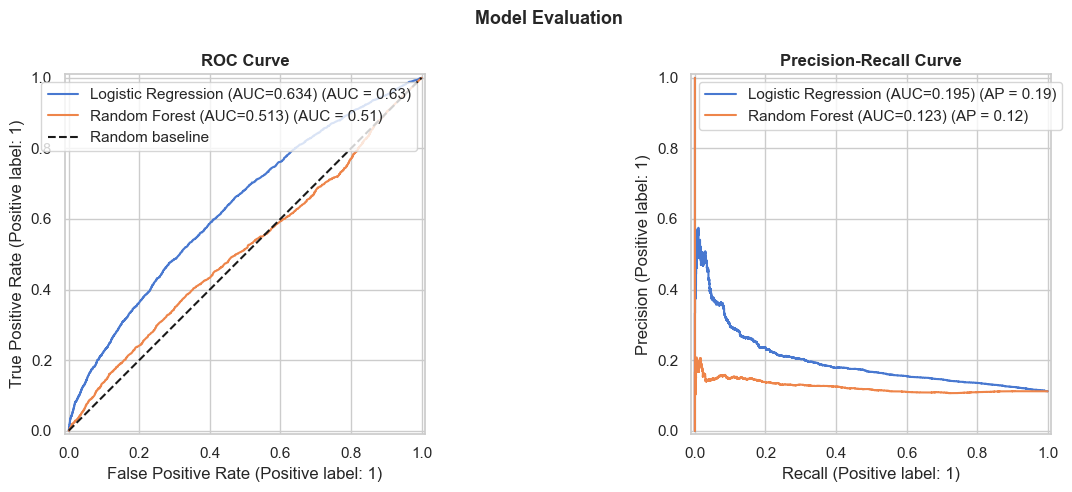

In [6]:
# ROC and Precision-Recall curves side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, lr_probs, name=f'Logistic Regression (AUC={lr_roc_auc:.3f})', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, rf_probs, name=f'Random Forest (AUC={rf_roc_auc:.3f})', ax=axes[0])
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, lr_probs, name=f'Logistic Regression (AUC={lr_pr_auc:.3f})', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, rf_probs, name=f'Random Forest (AUC={rf_pr_auc:.3f})', ax=axes[1])
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.suptitle('Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature importance

**Logistic Regression coefficients** tell us the direction and magnitude
of each feature's effect on readmission probability (after scaling).

**Random Forest feature importances** measure how much each feature
reduces impurity across all trees — a different but complementary view.

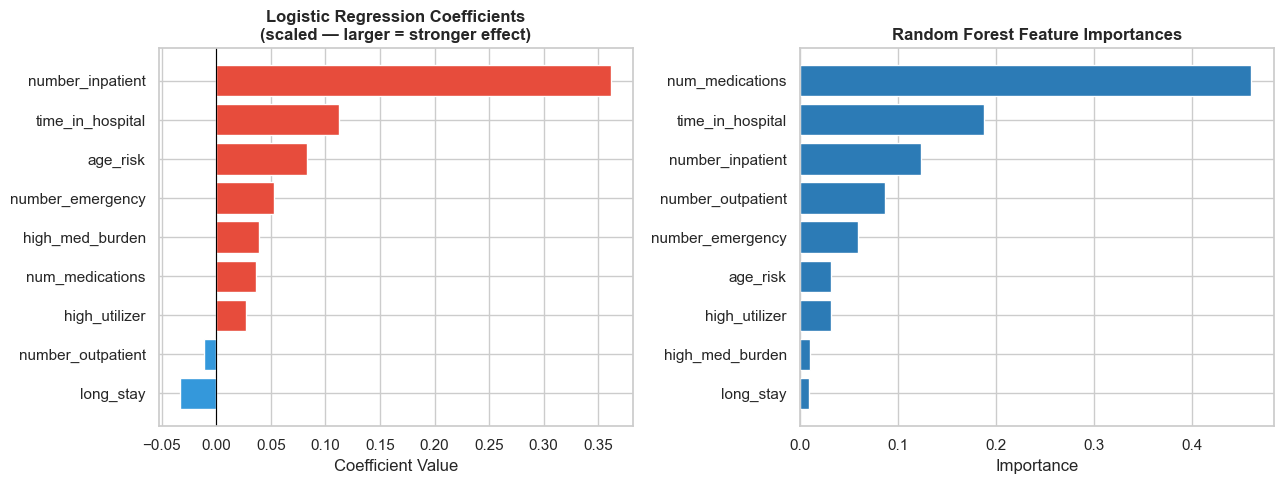

Top 3 features (Random Forest):
  num_medications           0.461
  time_in_hospital          0.188
  number_inpatient          0.123


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Logistic Regression coefficients
lr_coefs = pd.Series(
    lr_pipeline.named_steps['model'].coef_[0],
    index=FEATURE_COLS
).sort_values()

colors = ['#e74c3c' if c > 0 else '#3498db' for c in lr_coefs.values]
axes[0].barh(lr_coefs.index, lr_coefs.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression Coefficients\n(scaled — larger = stronger effect)', fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# Random Forest feature importances
rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values()

axes[1].barh(rf_importances.index, rf_importances.values, color='#2c7bb6')
axes[1].set_title('Random Forest Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('Top 3 features (Random Forest):')
for feat, imp in rf_importances.sort_values(ascending=False).head(3).items():
    print(f'  {feat:<25} {imp:.3f}')

## 7. Confusion matrix at default threshold (0.5)

At the default 0.5 threshold, we can see how the model trades off
false positives vs false negatives. In clinical settings, the threshold
is often lowered to catch more true positives (higher recall) at the
cost of more false alarms — a clinical decision, not a model decision.

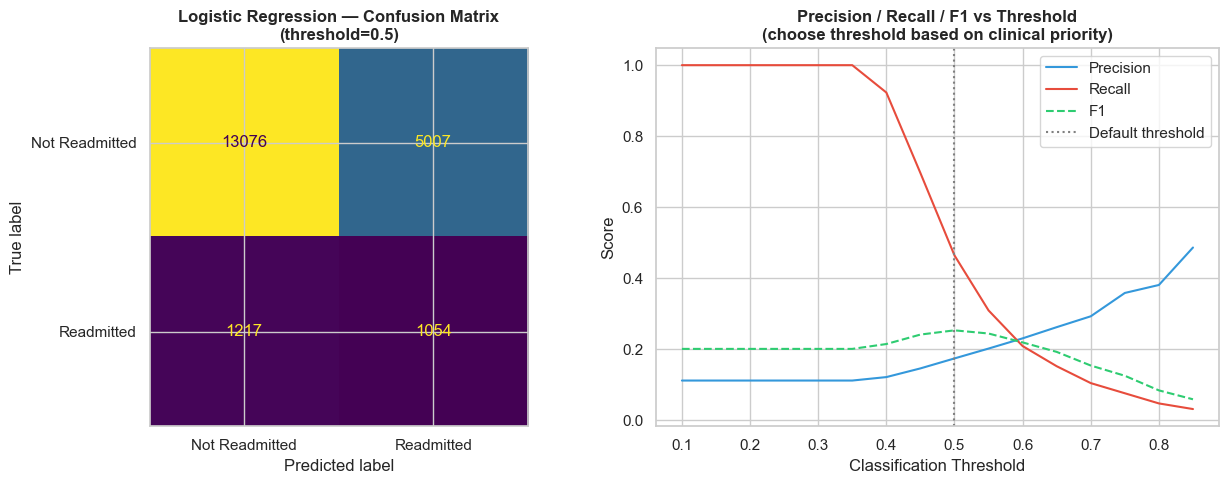


Classification report (Logistic Regression, threshold=0.5):
                precision    recall  f1-score   support

Not Readmitted       0.91      0.72      0.81     18083
    Readmitted       0.17      0.46      0.25      2271

      accuracy                           0.69     20354
     macro avg       0.54      0.59      0.53     20354
  weighted avg       0.83      0.69      0.75     20354



In [8]:
# Use the better-performing model for the confusion matrix
best_model_name = 'Random Forest' if rf_roc_auc >= lr_roc_auc else 'Logistic Regression'
best_probs = rf_probs if rf_roc_auc >= lr_roc_auc else lr_probs

y_pred = (best_probs >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Readmitted', 'Readmitted']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_model_name} — Confusion Matrix\n(threshold=0.5)', fontweight='bold')

# Threshold sensitivity: precision, recall, F1 across thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (best_probs >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

axes[1].plot(thresholds, precisions, label='Precision', color='#3498db')
axes[1].plot(thresholds, recalls, label='Recall', color='#e74c3c')
axes[1].plot(thresholds, f1s, label='F1', color='#2ecc71', linestyle='--')
axes[1].axvline(0.5, color='gray', linestyle=':', label='Default threshold')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold\n(choose threshold based on clinical priority)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nClassification report ({best_model_name}, threshold=0.5):')
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))

## 8. Cross-validation (robustness check)

A single train/test split can be lucky or unlucky. 5-fold cross-validation
gives a more reliable estimate of true model performance by averaging
results across 5 different train/test splits.

In [9]:
print('Running 5-fold cross-validation (this may take ~30 seconds)...')

lr_cv_scores = cross_val_score(lr_pipeline, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)

print('\n5-Fold Cross-Validation ROC-AUC')
print('=' * 45)
for name, scores in [('Logistic Regression', lr_cv_scores), ('Random Forest', rf_cv_scores)]:
    print(f'{name:<25}  mean={scores.mean():.3f}  std={scores.std():.3f}  [{" ".join(f"{s:.3f}" for s in scores)}]')

Running 5-fold cross-validation (this may take ~30 seconds)...



5-Fold Cross-Validation ROC-AUC
Logistic Regression        mean=0.631  std=0.005  [0.636 0.635 0.625 0.633 0.625]
Random Forest              mean=0.510  std=0.005  [0.514 0.512 0.515 0.504 0.503]


## 9. Summary & clinical interpretation

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| ROC-AUC (test) | — | — |
| PR-AUC (test) | — | — |
| CV ROC-AUC (mean ± std) | — | — |

*(Values filled in after execution)*

### Clinical context

- Published 30-day readmission models typically achieve **AUC-ROC 0.65–0.75**
  using administrative data alone. EHR-based models with lab values and
  nursing notes can reach ~0.80.
- Our feature set is limited to administrative/utilization data from this
  public dataset — performance in that range is expected and honest.
- **Prior inpatient visits** consistently emerges as the strongest predictor,
  consistent with the clinical literature (Robinson et al., 2015).
- The threshold analysis (section 7) shows the precision/recall tradeoff.
  In practice, a clinical team would lower the threshold to ~0.3–0.4
  to prioritize catching more high-risk patients (higher recall) at the
  cost of more false positives requiring intervention review.

### Limitations

- Dataset is from 1999–2008; treatment patterns have changed significantly
- No lab values, diagnosis codes, or social determinants of health included
- Feature engineering thresholds (e.g., LOS ≥ 7 days) were set based on
  clinical convention, not optimized — future work could tune these

### Next steps

- Add ICD diagnosis codes as features (currently available but unused)
- Try XGBoost or LightGBM for potentially stronger performance
- Implement SHAP values for individual-level explainability
- Hyperparameter tuning via GridSearchCV